In [14]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from math import pi, sqrt
import pandas as pd

# Constants

In [15]:
# param
ODE_SOLVE_METHOD = 'RK45'  # 'Radau', 'BDF', 'LSODA', 'RK45', etc.

# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
e_charge = 1.602176634e-19  # Elementary charge, C
hbar = h / (2 * np.pi)    # Reduced Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters of R(56) 32–0 (assumed to be the a10 hyperfine peak) ---
# R branch -> ΔJ = +1
# J'' = 56 (ground state), J' = 57
# v'' = 0 (ground vibrational state), v' = 32 (excited vibrational state)
k_a_10 = 18788.348        # cm-1
f_a_10 = k_a_10 * c * 100  # Hz
# f_a_1_to_a_10 = 571e6 # Hz, a1 to a10 hyperfine splitting
print(f"a10 wavelength λ = {c/f_a_10*1e9:.2f} nm")
linewidth = 37e6

# Rb vapor number density (low-pressure) (assumed)
T = 273.15 + 25 # K
# L_cell = 5
# P_mbar = 0.05 # 10^-1 to 10^-2 mbar
# P_Pa = P_mbar * 100 # convert to Pascals
# N = P_Pa / (k_B * T)  # ideal gas law, m^-3
# print(f"I2 vapor number density N = {N/1e16:.2f} x10^16 m^-3 at T = {T:.2f} K")

# D_mode = 31e-6 # m, beam diameter at the PMC

# in power
# P_tot = 7e-3
PBS_ratio = 1/9 # 1 : 9 probe to pump power ratio
# P_probe = P_tot * 1/(1 + 1/PBS_ratio) / 2 * 0.25 / 2 / 2# /2 for the second PBS, 0.25 for the coupling efficiency to the PMC, /2 again for the PBS before PD1
# print(f"Probe to total ratio = 1 : {P_tot/P_probe:.1f}, P_probe = {P_probe*1e3:.2f} mW")

# alpha of iodine
sigma = 3.03e-18 * 1e-4

# laser source
laser_linewidth = 200e3 # Hz


a10 wavelength λ = 532.24 nm


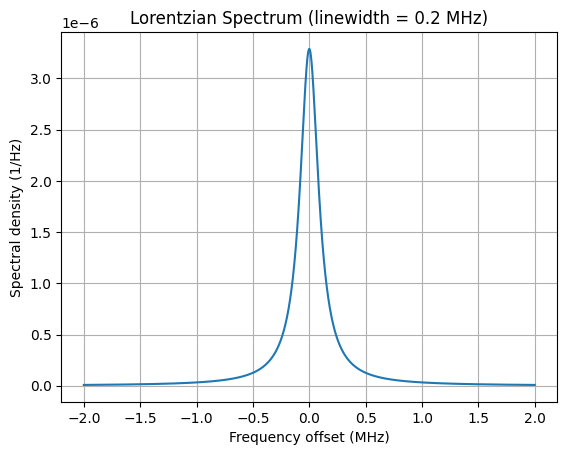

Integral = 1.0000000000000002


In [16]:
# --- spectrum of laser ---

# --- Parameters ---
lambda_temp = 1064e-9  # central wavelength (m)

# Convert central wavelength to frequency
f_temp = c / lambda_temp  # central frequency (Hz)

# --- Frequency axis ---
# Span several linewidths to capture the full distribution
span = 10 * laser_linewidth
f_array = np.linspace(f_temp - span, f_temp + span, 10000)

# --- Lorentzian function ---
# L(f) = (1/pi) * ( (gamma/2) / [ (f - f0)^2 + (gamma/2)^2 ] )
gamma = laser_linewidth  # FWHM

lorentzian = (1/np.pi) * ( (gamma/2) / ((f_array - f_temp)**2 + (gamma/2)**2) )

# --- Normalize (numerically, just to be safe) ---
lorentzian /= np.trapezoid(lorentzian, f_array)

# --- Plot ---
plt.figure()
plt.plot((f_array - f_temp)/1e6, lorentzian)  # frequency offset in MHz
plt.xlabel("Frequency offset (MHz)")
plt.ylabel("Spectral density (1/Hz)")
plt.title(f"Lorentzian Spectrum (linewidth = {laser_linewidth/1e6} MHz)")
plt.grid()
plt.show()

# --- Check normalization ---
print("Integral =", np.trapezoid(lorentzian, f_array))

   Frequency (MHz)  Transmission
0         -5.00000      0.000001
1         -4.98999      0.000001
2         -4.97998      0.000001
3         -4.96997      0.000001
4         -4.95996      0.000001


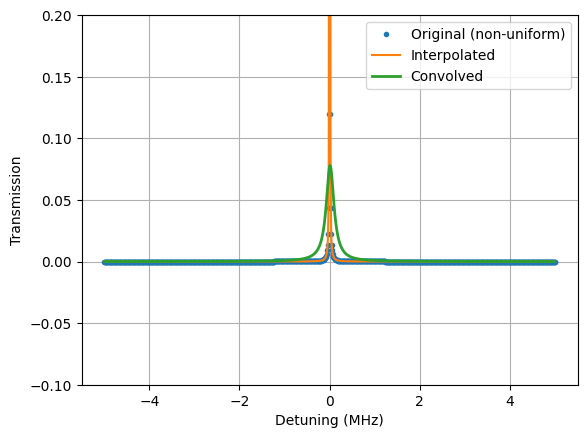

In [25]:
# =========================
# 1. Load data
# =========================
# data = pd.read_csv("../fig_to_txt/I2 cell hyperfine.csv")
# make temporary data: a lorentzian centered at zero with FWHM 0.85 MHz
f_temp = 0
gamma_temp = 0.003 # MHz
f_temp_array = np.linspace(-5, 5, 1000) # MHz
T_temp_array = (1/np.pi) * ( (gamma_temp/2) / ((f_temp_array - f_temp)**2 + (gamma_temp/2)**2) )
T_temp_array /= np.max(T_temp_array) # normalize to 1
data = pd.DataFrame({'Frequency (MHz)': f_temp_array, 'Transmission': T_temp_array})
print(data.head())

f_raw = data.iloc[:, 0].values  # MHz (non-uniform)
T_raw = data.iloc[:, 1].values

# Sort (important)
idx = np.argsort(f_raw)
f_raw = f_raw[idx]
T_raw = T_raw[idx]

# =========================
# 2. Create uniform grid
# =========================
# df = np.mean(np.diff(f_raw))  # safest resolution
df = 0.01
f_uniform = np.arange(f_raw.min(), f_raw.max(), df)

# Interpolate
interp_func = interp1d(f_raw, T_raw, kind='linear', fill_value="extrapolate")
T_uniform = interp_func(f_uniform)

# =========================
# 3. Lorentzian kernel
# =========================
gamma = laser_linewidth / 1e6  # convert to MHz for consistency with f_uniform

f_kernel = np.arange(-len(f_uniform)//2, len(f_uniform)//2) * df

S_L = (1/np.pi) * ((gamma/2) / (f_kernel**2 + (gamma/2)**2))

# Normalize
S_L /= np.sum(S_L) * df

# =========================
# 4. Convolution
# =========================
T_meas = np.convolve(T_uniform, S_L, mode='same') * df

# =========================
# 5. Plot
# =========================
plt.figure()
plt.plot(f_raw, T_raw, 'o', label="Original (non-uniform)", markersize=3)
plt.plot(f_uniform, T_uniform, label="Interpolated")
plt.plot(f_uniform, T_meas, label="Convolved", linewidth=2)

plt.xlabel("Detuning (MHz)")
plt.ylabel("Transmission")
plt.legend()
plt.grid()
# plt.xlim(250,300)
plt.ylim(-0.1,0.2)
plt.show()